In [1]:
import math
import numpy as np

# Given logits
logits = [2.0, 1.0, 0.1]

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

# Apply sigmoid to each logit
sigmoid_outputs = [sigmoid(x) for x in logits]

# Softmax function
def softmax(x):
    exp_vals = np.exp(x)
    return exp_vals / np.sum(exp_vals)

softmax_outputs = softmax(np.array(logits))

# Print results
print("Logits:", logits)
print("\nSigmoid Outputs:")
for i, val in enumerate(sigmoid_outputs):
    print(f"Class {i}: {val:.4f}")

print("\nSoftmax Outputs:")
for i, val in enumerate(softmax_outputs):
    print(f"Class {i}: {val:.4f}")

print("\nSum of Sigmoid outputs:", sum(sigmoid_outputs))
print("Sum of Softmax outputs:", np.sum(softmax_outputs))


Logits: [2.0, 1.0, 0.1]

Sigmoid Outputs:
Class 0: 0.8808
Class 1: 0.7311
Class 2: 0.5250

Softmax Outputs:
Class 0: 0.6590
Class 1: 0.2424
Class 2: 0.0986

Sum of Sigmoid outputs: 2.1368348440868274
Sum of Softmax outputs: 1.0


In [2]:
import numpy as np
import math
import torch
import torch.nn.functional as F

# Logits
logits = np.array([2.0, 1.0, 0.1])

# ---------- Softmax (manual) ----------
exp_vals = np.exp(logits)
softmax_probs = exp_vals / np.sum(exp_vals)

print("Softmax Probabilities:", softmax_probs)
print("Sum:", np.sum(softmax_probs))

# ---------- True class ----------
true_class = 0  # class index

# ---------- Cross Entropy (manual) ----------
manual_loss = -math.log(softmax_probs[true_class])
print("\nManual Cross Entropy Loss:", manual_loss)

# ---------- Cross Entropy using PyTorch ----------
logits_torch = torch.tensor([logits], dtype=torch.float32)
labels_torch = torch.tensor([true_class])

loss_torch = F.cross_entropy(logits_torch, labels_torch)

print("PyTorch Cross Entropy Loss:", loss_torch.item())


Softmax Probabilities: [0.65900114 0.24243297 0.09856589]
Sum: 1.0

Manual Cross Entropy Loss: 0.4170300162778335
PyTorch Cross Entropy Loss: 0.4170299470424652


C:\Users\LOKESH\AppData\Local\Temp\ipykernel_20052\3757578770.py:24: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  logits_torch = torch.tensor([logits], dtype=torch.float32)


Logits: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]

Softmax Probabilities: [0.16763982 0.08884021 0.19495956 0.46784333 0.08071708]
Sum of probabilities: 0.9999999999999999


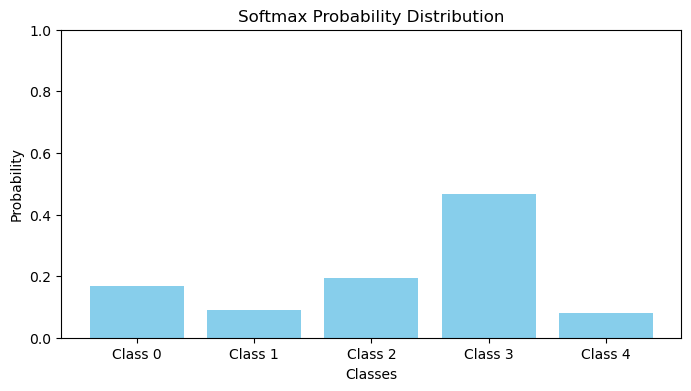


Boosted Logits: [ 5.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
Softmax Probabilities After Boosting: [0.96762796 0.00345516 0.00758234 0.0181953  0.00313924]
Sum of probabilities: 1.0


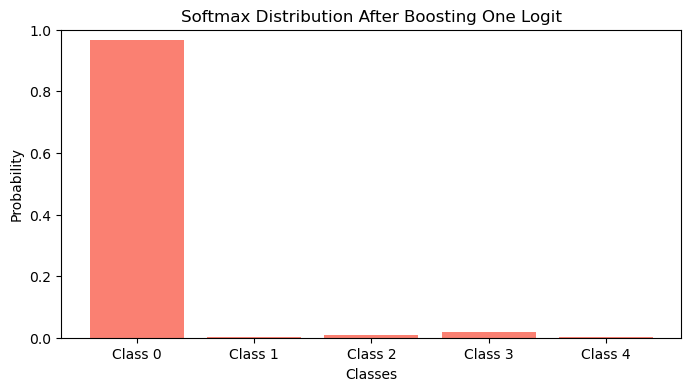

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Generate random logits
# -------------------------------
np.random.seed(42)              # for reproducibility
num_classes = 5
logits = np.random.randn(num_classes)

print("Logits:", logits)

# -------------------------------
# 2. Define Softmax function
# -------------------------------
def softmax(x):
    exp_vals = np.exp(x)
    return exp_vals / np.sum(exp_vals)

# Apply softmax
probabilities = softmax(logits)

print("\nSoftmax Probabilities:", probabilities)
print("Sum of probabilities:", np.sum(probabilities))

# -------------------------------
# 3. Plot Softmax probabilities
# -------------------------------
classes = [f"Class {i}" for i in range(num_classes)]

plt.figure(figsize=(8, 4))
plt.bar(classes, probabilities, color="skyblue")
plt.ylabel("Probability")
plt.xlabel("Classes")
plt.title("Softmax Probability Distribution")
plt.ylim(0, 1)
plt.show()

# -------------------------------
# 4. Boost one logit to show dominance
# -------------------------------
logits_boosted = logits.copy()
logits_boosted[0] += 5          # increase one logit significantly

print("\nBoosted Logits:", logits_boosted)

boosted_probabilities = softmax(logits_boosted)

print("Softmax Probabilities After Boosting:", boosted_probabilities)
print("Sum of probabilities:", np.sum(boosted_probabilities))

# -------------------------------
# 5. Plot boosted Softmax probabilities
# -------------------------------
plt.figure(figsize=(8, 4))
plt.bar(classes, boosted_probabilities, color="salmon")
plt.ylabel("Probability")
plt.xlabel("Classes")
plt.title("Softmax Distribution After Boosting One Logit")
plt.ylim(0, 1)
plt.show()


In [2]:
import numpy as np
import random

# 1. Vocabulary
vocab = ["I", "like", "machine", "translation"]

# 2. Softmax function
def softmax(logits):
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits)

# 3. Greedy decoding
def greedy_decode(probabilities):
    return np.argmax(probabilities)

# 4. Random sampling
def random_sampling(probabilities):
    return np.random.choice(len(probabilities), p=probabilities)

# -------------------------
# Step 1: After "I"
logits_step1 = np.array([1.2, 2.5, 0.3, 1.0])
probs_step1 = softmax(logits_step1)

print("Step 1 Probabilities:")
for word, prob in zip(vocab, probs_step1):
    print(f"{word}: {prob:.2f}")

# Greedy decoding
word_index = greedy_decode(probs_step1)
sentence = ["I", vocab[word_index]]
print("\nGreedy Decoding Result:", " ".join(sentence))

# Random sampling
sampled_index = random_sampling(probs_step1)
print("Random Sampling Result:", "I", vocab[sampled_index])

# -------------------------
# Step 2: After "I like"
logits_step2 = np.array([0.2, 0.1, 2.8, 1.9])
probs_step2 = softmax(logits_step2)

print("\nStep 2 Probabilities:")
for word, prob in zip(vocab, probs_step2):
    print(f"{word}: {prob:.2f}")

word_index = greedy_decode(probs_step2)
sentence.append(vocab[word_index])
print("\nSentence so far:", " ".join(sentence))

# -------------------------
# Step 3: After "I like machine"
logits_step3 = np.array([0.1, 0.2, 0.3, 3.0])
probs_step3 = softmax(logits_step3)

word_index = greedy_decode(probs_step3)
sentence.append(vocab[word_index])

print("\nFinal Generated Sentence:")
print(" ".join(sentence))


Step 1 Probabilities:
I: 0.17
like: 0.62
machine: 0.07
translation: 0.14

Greedy Decoding Result: I like
Random Sampling Result: I I

Step 2 Probabilities:
I: 0.05
like: 0.04
machine: 0.65
translation: 0.26

Sentence so far: I like machine

Final Generated Sentence:
I like machine translation
